## SafeDerm — Gateway 2 Trial: Near-OOD via k-NN (on baseline.pt)

Standalone validation notebook, same spirit as `09_gateway_threshold_tuning.ipynb` — not part of the numbered 01-08 pipeline.

Built on `baseline_resnet50.pt` as a first trial. When the champion checkpoint lands, re-run this notebook against it — the feature bank is model-specific and needs rebuilding, but the code doesn't change.

Goal: confirm that images which fool Gateway 1 (BiomedCLIP) — like the wood-grain and glitter/confetti images we ran into manually — sit far from the real training distribution in the baseline model's own embedding space.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader

from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH, MODELS_DIR, CHAMPION_MODEL_PATH
from src.dataset import SkinLesionDataset
from src.transforms import get_eval_transforms
from src.model import build_champion_model
import src.near_ood as near_ood

from src.near_ood import (
    build_feature_bank,
    save_feature_bank,
    load_feature_bank_if_exists,
    champion_embedding_fn,
)

embedding_fn = champion_embedding_fn


### Load the baseline checkpoint

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_champion_model().to(device)
model.load_state_dict(torch.load(CHAMPION_MODEL_PATH, map_location=device))
model.eval()
print(f"Loaded champion checkpoint on {device}")


Loaded champion checkpoint on cuda


### Build the feature bank

One forward pass over the full train split (eval transform, no augmentation — we want each image's "true" embedding, not an augmented view). This is the one-time cost; every later `/predict` call just does a single distance lookup against it.

In [3]:
eval_transform = get_eval_transforms()

train_dataset = SkinLesionDataset(TRAIN_SPLIT_PATH, IMAGES_DIR, transform=eval_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

bank = build_feature_bank(model, train_loader, device=str(device), embedding_fn=embedding_fn)
print(f"Feature bank: {bank.embeddings.shape[0]} embeddings, dim {bank.embeddings.shape[1]}")

Feature bank: 6981 embeddings, dim 256


In [4]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
saved_path = save_feature_bank(bank, MODELS_DIR)
champion_path = MODELS_DIR / "feature_bank_champion.pt"
if saved_path.exists():
    if champion_path.exists():
        champion_path.unlink()
    saved_path.rename(champion_path)
print(f"Saved to {champion_path}")

Saved to D:\Important\00-Projects\SafeDerm\models\feature_bank_champion.pt


### Sanity check — distance for real skin images (held-out val split)

These should score low — they're genuinely in-distribution, just not seen during feature-bank construction.

In [5]:
from src.config import VAL_SPLIT_PATH

eval_transform = get_eval_transforms()
val_dataset = SkinLesionDataset(VAL_SPLIT_PATH, IMAGES_DIR, transform=eval_transform)

N_VAL_SAMPLES = 20
val_distances = []
bank.embeddings = bank.embeddings.to(
    device=next(model.parameters()).device,
    dtype=next(model.parameters()).dtype
)
for i in range(N_VAL_SAMPLES):
    image_tensor, _label = val_dataset[i]
    dist = near_ood.knn_distance(image_tensor.unsqueeze(0), model, bank, embedding_fn)
    val_distances.append(dist)

print(f"Real skin (val) distances — min: {min(val_distances):.3f}  max: {max(val_distances):.3f}")

Real skin (val) distances — min: 2.695  max: 9.980


### The edge cases — wood grain and glitter

Drop `wood_grain.jpg` and `glitter.jpg` (the two images that confused Gateway 1) into `notebooks/gateway_ood_samples/` and run this cell. Expectation: their distances should sit clearly above the real-skin range above.

In [11]:
edge_case_paths = {
    "wood_grain": "gateway_ood_samples/wood_grain.jpg",
    "glitter": "gateway_ood_samples/glitter.jpg",
}

edge_case_distances = {}
for name, path in edge_case_paths.items():
    image = Image.open(path).convert("RGB")
    image_tensor = eval_transform(image).unsqueeze(0)
    dist = near_ood.knn_distance(image_tensor, model, bank, embedding_fn)
    edge_case_distances[name] = dist
    print(f"{name}: distance = {dist:.3f}")

wood_grain: distance = 7.636
glitter: distance = 5.180


### Compare distributions

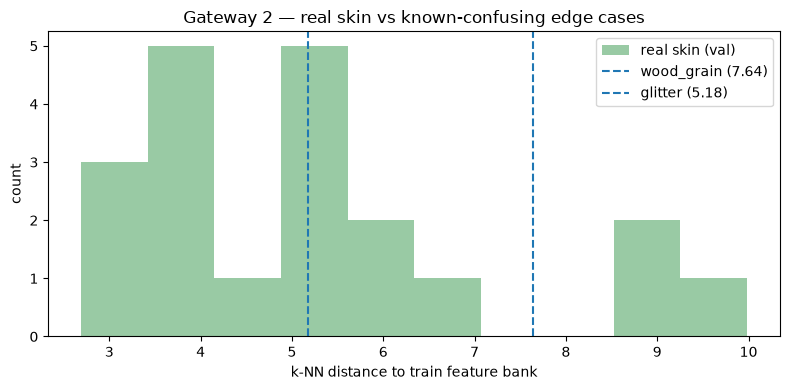

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(val_distances, bins=10, alpha=0.6, label="real skin (val)", color="#55A868")
for name, dist in edge_case_distances.items():
    ax.axvline(dist, linestyle="--", label=f"{name} ({dist:.2f})")
ax.set_xlabel("k-NN distance to train feature bank")
ax.set_ylabel("count")
ax.set_title("Gateway 2 — real skin vs known-confusing edge cases")
ax.legend()
plt.tight_layout()
plt.show()

### Decide the distance threshold

If the edge-case distances sit clearly to the right of the real-skin histogram, pick a threshold in that gap and set `DEFAULT_DISTANCE_THRESHOLD` in `src/near_ood.py`. If they overlap, that's worth flagging to the team — it means k-NN alone isn't separating these cases cleanly on the baseline model, and it's worth re-checking once the champion checkpoint is available (better features may separate them better).

In [ ]:
# CHOSEN_DISTANCE_THRESHOLD = 0.xx  # fill in after reviewing the histogram above